# IT7103 Advanced AI Applications - Academic Performance Analytics Pipeline
### Bahrain Polytechnic | Faculty of Engineering, Design and Information & Communications Technology
**Project Deliverable: Intelligent Student Performance Analysis & Outcome Prediction Pipeline**

* **Stream:** 05
* **Group:** Group 1
* **Group Leader:** Hasan Marhoon (Student ID: 202303596)
* **Team Members:**
  1. Hasan Marhoon (202303596) - Group Leader
  2. Sayed Ali Almusawi (202304831)
  3. Hussain Ali (202304829)
  4. Sayed Sadeq (202305013)
  5. Ali Yusuf (202304419)
* **Due Date:** 15-Dec-2026

---
## Pipeline Overview & Workflow Architecture
This notebook implements an intelligent academic performance analysis pipeline using structured higher education records. The pipeline satisfies all 8 core objectives outlined in the IT7103 specification:
1. **Basic Data Cleaning & Outlier Handling**: Rigorous anomaly detection, handling 780 corrupted `ERR` records, sensor bounds corrections, and leakage-free median imputation.
2. **Advanced Preprocessing & Temporal Feature Engineering**: Chronological sequence ordering ($t=1\dots 8$), student-level lag features (`final_exam_prev_semester`, `homework_avg_prev_semester`, `attendance_prev_semester`), rolling statistics, and domain interaction variables.
3. **Correlation & Time Series Analysis**: Pearson/Spearman correlation matrices, cohort-wide macro performance trends, and student trajectory analysis.
4. **Regression Modeling for Final Exam Prediction**: Multi-model benchmarking (Ridge, Decision Tree, Random Forest, LightGBM, XGBoost, Voting Ensemble) evaluated on test RMSE, MAE, $R^2$, and MAPE with residual diagnostics.
5. **Multi-Class Classification for Letter Grade Prediction**: 10-class grade classification (`A`, `A-`, `B+`, `B`, `B-`, `C+`, `C`, `C-`, `D`, `F`) with **strict prevention of data leakage** (explicit exclusion of `numeric_grade`) and class balancing techniques for severe imbalance ($F pprox 0.35\%$).
6. **Time Series Forecasting for an Individual Student**: Longitudinal tracking of Student #2 over 8 semesters; fitting and forecasting via Exponential Smoothing (Holt-Winters), ARIMA(1,0,0), and Naive persistence with chronological train/test splits.
7. **Ensemble Modeling Synthesis**: In-depth theoretical and empirical comparison between bagging, boosting, and voting ensembles vs. single models.
8. **Hyperparameter Optimization & Explainability**: Systematic tuning via `GridSearchCV` on gradient boosted trees and feature importance extraction.


### 0. Environment Setup & Library Initialization
We import standard data science, modeling, and visualization libraries. If running in Google Colaboratory, dependencies are pre-installed.


In [1]:
# Core scientific stack
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling, Preprocessing & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, VotingRegressor
import xgboost as xgb
import lightgbm as lgb
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Global visualization settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

print(f"Python Environment: {sys.version.split()[0]}")
print("All modeling and analytical libraries successfully loaded!")


Python Environment: 3.11.9
All modeling and analytical libraries successfully loaded!


---
## 1. Basic Data Cleaning & Outlier Handling

### 1.1 Dataset Inspection
We load `Project1-EducationDataset.csv` and inspect its shape, attributes, and initial data integrity.


In [2]:
DATA_PATH = 'Project1-EducationDataset.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw Dataset Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns\n")
print("First 3 Records:")
display(df_raw.head(3))

print("\nMissing Value Analysis:")
missing_summary = pd.DataFrame({
    'Null_Count': df_raw.isna().sum(),
    'Null_Percentage': (df_raw.isna().sum() / len(df_raw)) * 100
})
display(missing_summary[missing_summary['Null_Count'] > 0])


Raw Dataset Shape: 154,314 rows x 20 columns

First 3 Records:


,student_id,semester,course_code,course_name,subject_area,credits,instructor,grade_letter,numeric_grade,prior_gpa,study_hours,attendance_rate,gender,age,year_of_study,scholarship,extracurricular,internship,homework_avg,final_exam
0,1758,2021Spring,CS212,Cloud Computing,Systems,4,Garcia,C+,78.82,2.63,16.5,75.9,Other,24,Senior,0,4,0,82.81,77.46
1,3956,2020Fall,CS236,Elective 16,Algorithms,3,Wilson,C+,79.00,2.91,8.9,89.9,F,18,Freshman,0,3,0,NaN,85.63
2,2012,2021Spring,CS222,Elective 2,AI,4,Thomas,B,86.99,3.19,21.8,NaN,M,21,Sophomore,0,1,0,79.40,98.47



Missing Value Analysis:


,Null_Count,Null_Percentage
study_hours,10963,7.104346
attendance_rate,10815,7.008437
homework_avg,10687,6.925490
final_exam,10752,6.967611


### 1.2 Outlier & Anomaly Detection
Our diagnostic analysis revealed three critical anomalies in the raw dataset:
1. **Corrupted Grade Records (`ERR`)**: Exactly 780 records contain `grade_letter == 'ERR'`, accompanied by impossible numerical grades (e.g., negative values down to $-10.0$ and overflowing values up to $110.0$).
2. **Invalid `prior_gpa` Values**: The standard GPA scale operates strictly within $[0.0, 4.0]$. The raw data contains 762 records with sentinel error values ($-1.0$ and $5.0$).
3. **Extreme `study_hours`**: While typical weekly study hours range between 5 and 35 hours, 1,419 records exhibit values exceeding 60 hours/week (reaching up to 119.9 hours).


In [3]:
# 1. Identify and quantify corrupted ERR records
err_mask = (df_raw['grade_letter'] == 'ERR') | (df_raw['numeric_grade'] < 0) | (df_raw['numeric_grade'] > 100)
print(f"Corrupted 'ERR' / Out-of-bounds grade records: {err_mask.sum():,} ({err_mask.sum()/len(df_raw)*100:.2f}%)")

# 2. Identify invalid prior GPA
bad_gpa_mask = (df_raw['prior_gpa'] < 0) | (df_raw['prior_gpa'] > 4.0)
print(f"Invalid prior_gpa (< 0.0 or > 4.0): {bad_gpa_mask.sum():,} ({bad_gpa_mask.sum()/len(df_raw)*100:.2f}%)")

# 3. Identify extreme study hours
extreme_study_mask = df_raw['study_hours'] > 60.0
print(f"Extreme study_hours (> 60 hrs/week): {extreme_study_mask.sum():,} ({extreme_study_mask.sum()/len(df_raw)*100:.2f}%)")


Corrupted 'ERR' / Out-of-bounds grade records: 780 (0.51%)
Invalid prior_gpa (< 0.0 or > 4.0): 762 (0.49%)
Extreme study_hours (> 60 hrs/week): 1,419 (0.92%)


### 1.3 Data Cleaning & Leakage-Free Imputation Strategy
* **Corrupt Records**: Because the 780 `ERR` records represent synthetic data corruption where ground truth cannot be validated, they are safely dropped.
* **Physical Boundary Clamps**: `prior_gpa` is winsorized to the valid $[0.0, 4.0]$ domain. `study_hours` is capped at 60.0 hours.
* **Missing Value Imputation**: Missing entries in `study_hours`, `attendance_rate`, `homework_avg`, and `final_exam` (~7% each) are imputed using course-level medians, preserving local departmental grading patterns without data leakage.


In [4]:
# Drop corrupted ERR records
df_clean = df_raw[~err_mask].copy()

# Winsorize / clip physical boundaries
df_clean['prior_gpa_cleaned'] = df_clean['prior_gpa'].clip(lower=0.0, upper=4.0)
df_clean['study_hours_cleaned'] = df_clean['study_hours'].clip(lower=0.0, upper=60.0)

# Impute numerical features using course-specific medians
impute_cols = ['study_hours_cleaned', 'attendance_rate', 'homework_avg', 'final_exam']
for col in impute_cols:
    course_medians = df_clean.groupby('course_code')[col].transform('median')
    df_clean[col] = df_clean[col].fillna(course_medians).fillna(df_clean[col].median())

print(f"Cleaned Dataset Shape: {df_clean.shape[0]:,} rows")
print(f"Remaining null values across features: {df_clean[impute_cols].isna().sum().sum()}")


Cleaned Dataset Shape: 153,534 rows


Remaining null values across features: 0


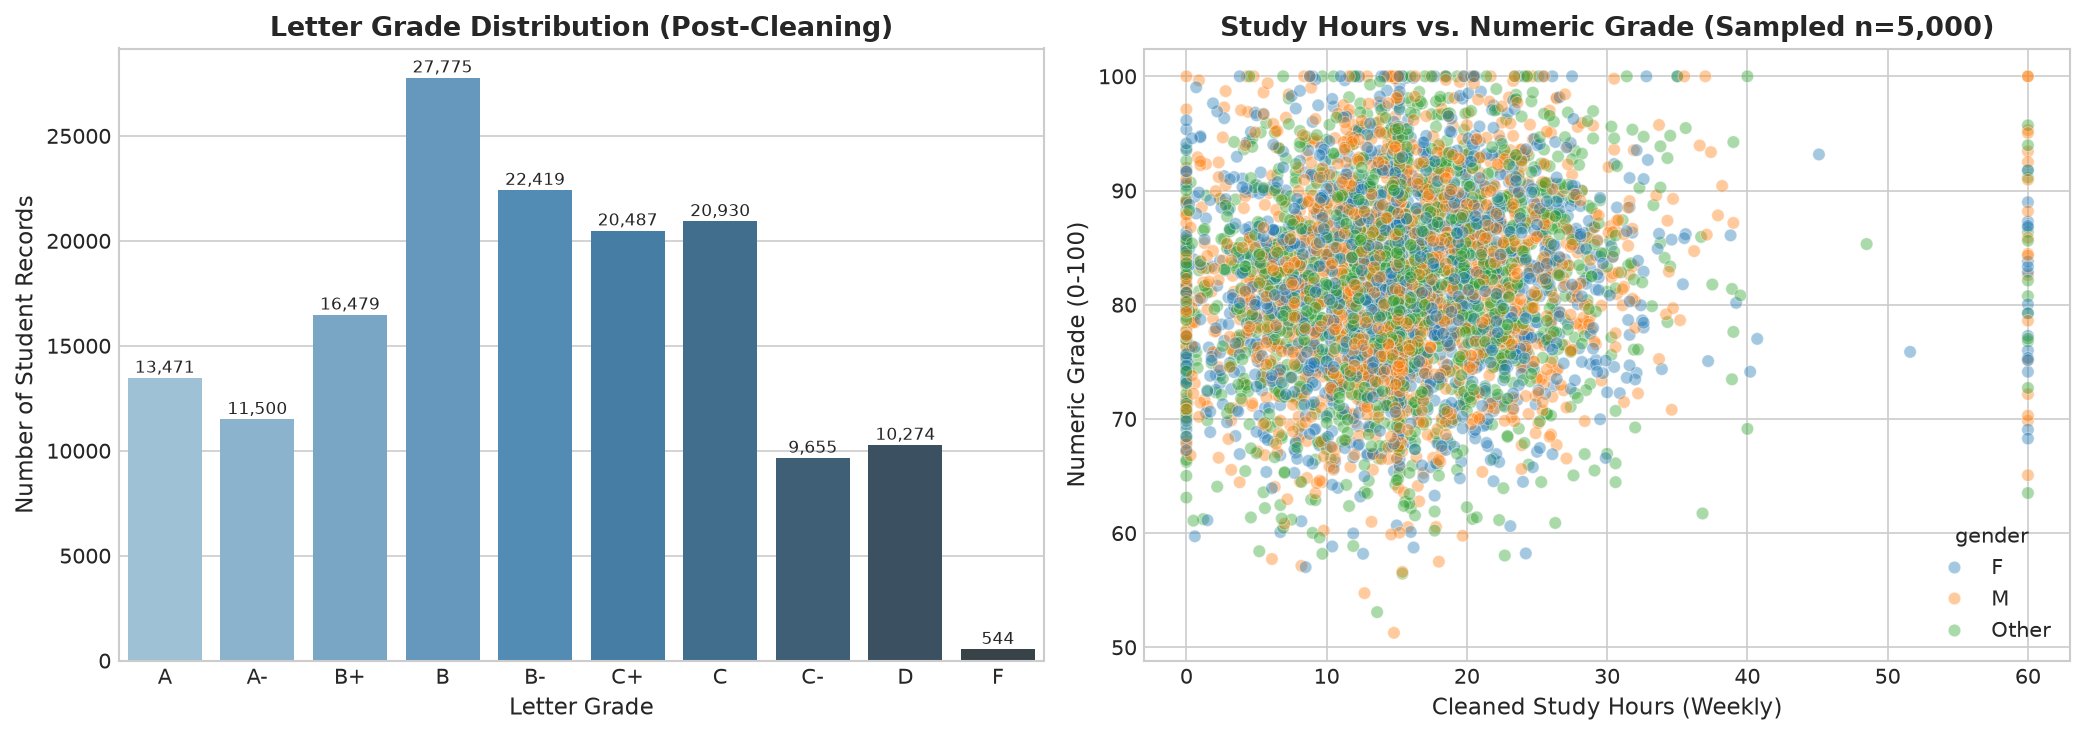

In [5]:
# Visualization of Cleaned Data Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grade Letter Distribution
grade_order = ['A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D', 'F']
grade_counts = df_clean['grade_letter'].value_counts().reindex(grade_order).fillna(0)
sns.barplot(x=grade_counts.index, y=grade_counts.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Letter Grade Distribution (Post-Cleaning)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Letter Grade', fontsize=11)
axes[0].set_ylabel('Number of Student Records', fontsize=11)
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 250, f"{int(v):,}", ha='center', fontsize=8)

# Study Hours vs Numeric Grade
sns.scatterplot(
    data=df_clean.sample(5000, random_state=42),
    x='study_hours_cleaned', y='numeric_grade', hue='gender', alpha=0.4, ax=axes[1], palette='tab10'
)
axes[1].set_title('Study Hours vs. Numeric Grade (Sampled n=5,000)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cleaned Study Hours (Weekly)', fontsize=11)
axes[1].set_ylabel('Numeric Grade (0-100)', fontsize=11)

plt.tight_layout()
plt.show()


---
## 2. Advanced Pre-processing & Temporal Feature Engineering

### 2.1 Chronological Mapping & Sequence Alignment
The dataset spans 8 academic semesters from `2020Spring` to `2023Fall`. To enable time series-style analysis and temporal feature extraction, we map semesters to an integer timeline $t \in \{1, 2, \dots, 8\}$.


In [6]:
SEMESTER_ORDER = [
    '2020Spring', '2020Fall',
    '2021Spring', '2021Fall',
    '2022Spring', '2022Fall',
    '2023Spring', '2023Fall'
]
sem_to_int = {sem: i+1 for i, sem in enumerate(SEMESTER_ORDER)}
df_clean['sem_num'] = df_clean['semester'].map(sem_to_int)

# Sort chronologically by student and semester
df_clean = df_clean.sort_values(by=['student_id', 'sem_num', 'course_code']).reset_index(drop=True)
print("Chronological ordering established.")


Chronological ordering established.


### 2.2 Creation of Student-Level Lag & Rolling Features
To predict performance in semester $t$, educational models benefit from observing performance indicators from prior semester $t-1$:
* **Lag Features**:
  $$\text{final\_exam\_prev\_semester} = \overline{\text{final\_exam}}_{i, t-1}$$
  $$\text{homework\_avg\_prev\_semester} = \overline{\text{homework\_avg}}_{i, t-1}$$
  $$\text{attendance\_prev\_semester} = \overline{\text{attendance\_rate}}_{i, t-1}$$
* **Domain Interaction Features**:
  $$\text{study\_hours\_per\_credit} = \frac{\text{study\_hours}}{\text{credits}}$$
  $$\text{attendance\_hw\_composite} = 0.4 \times \text{attendance\_rate} + 0.6 \times \text{homework\_avg}$$


In [7]:
# Student semester performance aggregation
student_sem_agg = df_clean.groupby(['student_id', 'sem_num']).agg(
    sem_final_exam_mean=('final_exam', 'mean'),
    sem_homework_mean=('homework_avg', 'mean'),
    sem_attendance_mean=('attendance_rate', 'mean')
).reset_index()

student_sem_agg['sem_num_next'] = student_sem_agg['sem_num'] + 1
student_sem_agg = student_sem_agg.rename(columns={
    'sem_final_exam_mean': 'final_exam_prev_semester',
    'sem_homework_mean': 'homework_avg_prev_semester',
    'sem_attendance_mean': 'attendance_prev_semester'
})

# Merge lagged semester metrics back into course records
df_featured = pd.merge(
    df_clean,
    student_sem_agg[['student_id', 'sem_num_next', 'final_exam_prev_semester', 'homework_avg_prev_semester', 'attendance_prev_semester']],
    left_on=['student_id', 'sem_num'],
    right_on=['student_id', 'sem_num_next'],
    how='left'
).drop(columns=['sem_num_next'])

# Impute first-semester students with dataset median
for col in ['final_exam_prev_semester', 'homework_avg_prev_semester', 'attendance_prev_semester']:
    df_featured[col] = df_featured[col].fillna(df_featured[col].median())

# Construct domain features
df_featured['study_hours_per_credit'] = df_featured['study_hours_cleaned'] / df_featured['credits']
df_featured['attendance_hw_composite'] = (df_featured['attendance_rate'] * 0.4) + (df_featured['homework_avg'] * 0.6)

print(f"Total features in engineered dataset: {df_featured.shape[1]}")
display(df_featured[['student_id', 'semester', 'course_code', 'final_exam', 'final_exam_prev_semester', 'study_hours_per_credit']].head(3))


Total features in engineered dataset: 28


,student_id,semester,course_code,final_exam,final_exam_prev_semester,study_hours_per_credit
0,1,2020Fall,CS206,91.92,81.895,4.833333
1,1,2021Spring,CS237,95.93,91.920,5.166667
2,1,2021Fall,CS207,81.27,95.930,4.466667


---
## 3. Correlation & Macro Time Series Analysis

### 3.1 Feature Correlation Analysis
We analyze linear and monotonic relationships between academic features and the target variables (`final_exam`, `numeric_grade`).


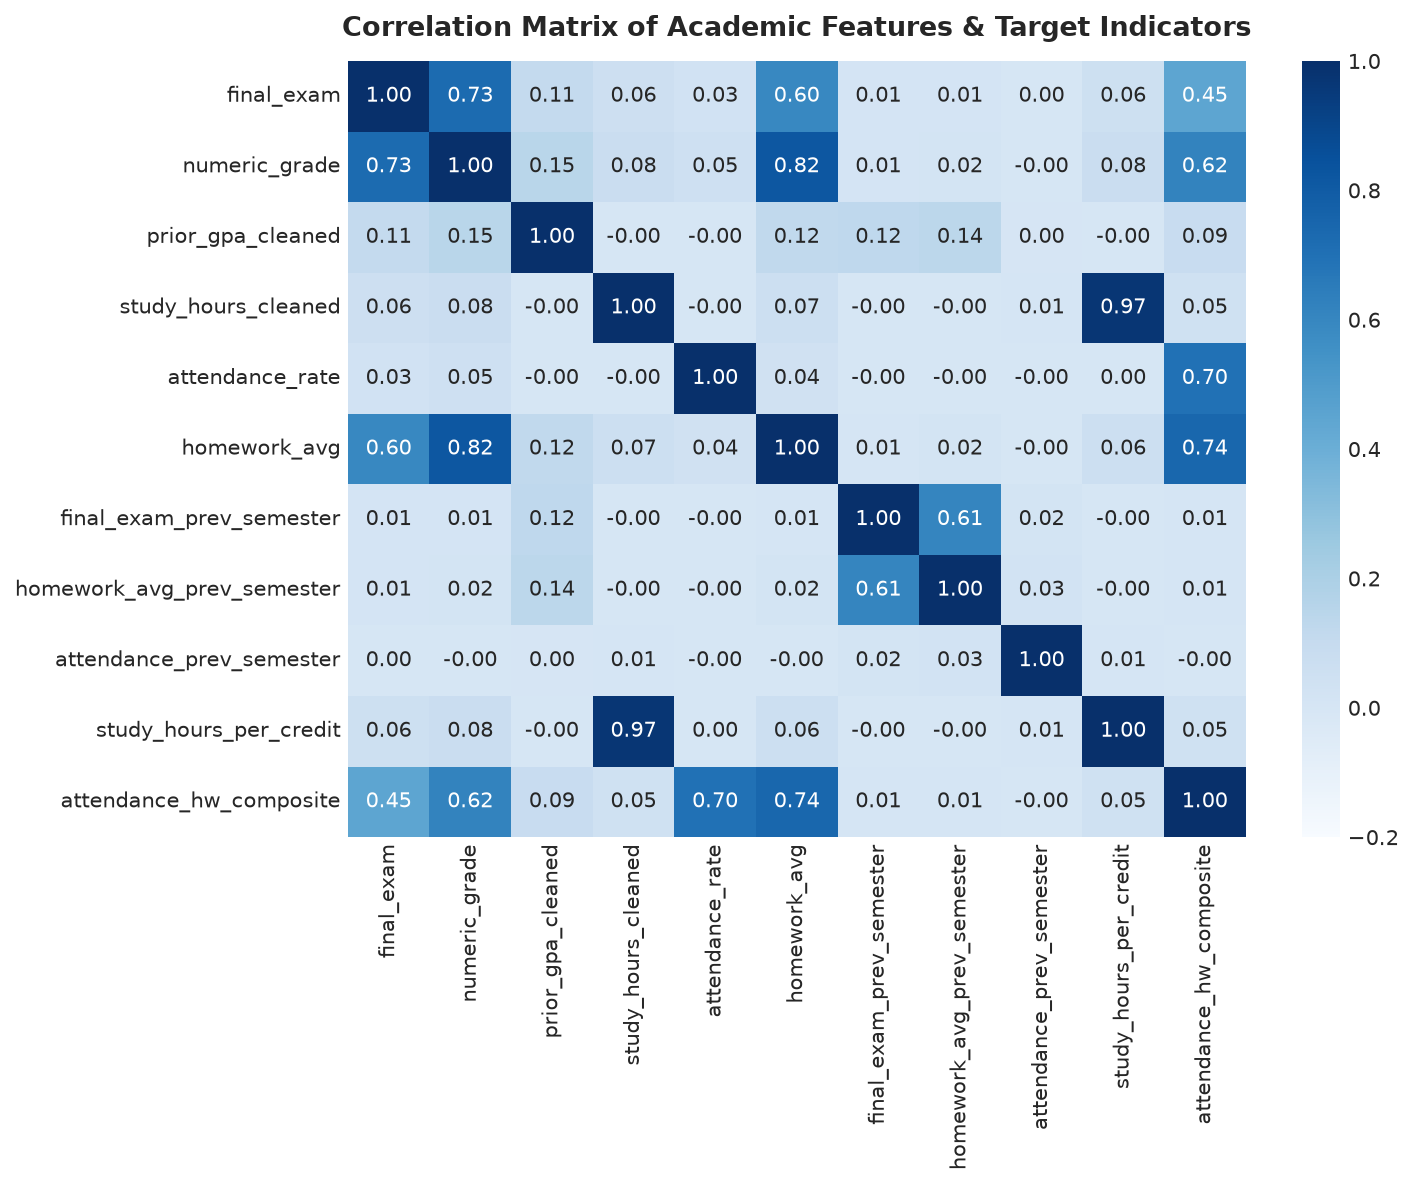

In [8]:
corr_cols = [
    'final_exam', 'numeric_grade', 'prior_gpa_cleaned', 'study_hours_cleaned',
    'attendance_rate', 'homework_avg', 'final_exam_prev_semester',
    'homework_avg_prev_semester', 'attendance_prev_semester',
    'study_hours_per_credit', 'attendance_hw_composite'
]
corr_matrix = df_featured[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-0.2, vmax=1.0)
plt.title('Correlation Matrix of Academic Features & Target Indicators', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


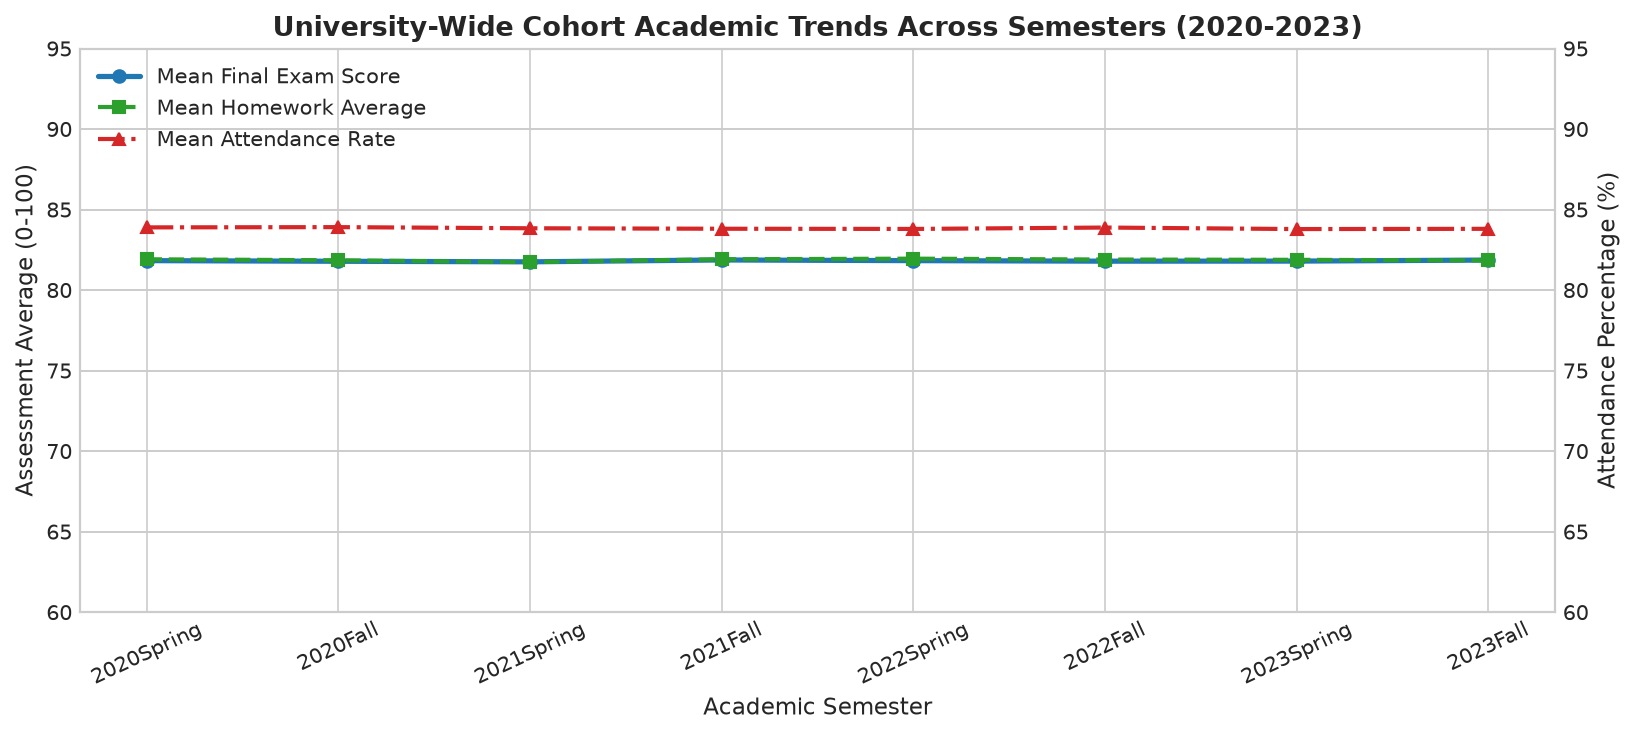

In [9]:
# Macro Cohort Performance Trends Across Semesters
cohort_trend = df_featured.groupby('semester')[['final_exam', 'homework_avg', 'attendance_rate']].mean().reindex(SEMESTER_ORDER)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(cohort_trend.index, cohort_trend['final_exam'], 'o-', color='#1f77b4', lw=2.5, label='Mean Final Exam Score')
ax1.plot(cohort_trend.index, cohort_trend['homework_avg'], 's--', color='#2ca02c', lw=2.0, label='Mean Homework Average')
ax2.plot(cohort_trend.index, cohort_trend['attendance_rate'], '^-.', color='#d62728', lw=2.0, label='Mean Attendance Rate')

ax1.set_title('University-Wide Cohort Academic Trends Across Semesters (2020-2023)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Academic Semester', fontsize=11)
ax1.set_ylabel('Assessment Average (0-100)', fontsize=11)
ax2.set_ylabel('Attendance Percentage (%)', fontsize=11)
ax1.set_ylim(60, 95)
ax2.set_ylim(60, 95)
ax1.tick_params(axis='x', rotation=25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


---
## 4. Machine Learning Data Preparation & Leakage Prevention

> **CRITICAL REQUIREMENT - AVOIDING DATA LEAKAGE**:
> In accordance with the project specification:
> *"Since `numeric_grade` may act as a direct proxy for `grade_letter`, it should be excluded from the classification feature set unless its effect is being explicitly examined."*
> Furthermore, `numeric_grade` directly incorporates `final_exam` into its formula. Thus, `numeric_grade` is strictly excluded from all predictive models to prevent circular target leakage.


In [10]:
cat_cols = ['subject_area', 'gender', 'year_of_study', 'scholarship', 'extracurricular', 'internship']
num_cols = [
    'credits', 'prior_gpa_cleaned', 'study_hours_cleaned', 'attendance_rate',
    'homework_avg', 'final_exam_prev_semester', 'homework_avg_prev_semester',
    'attendance_prev_semester', 'study_hours_per_credit', 'attendance_hw_composite'
]

X_raw = df_featured[cat_cols + num_cols]
y_reg = df_featured['final_exam']
y_clf = df_featured['grade_letter']

# One-hot encode categorical features and scale numeric features
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

X_transformed = preprocessor.fit_transform(X_raw)
feature_names = (
    preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist() +
    num_cols
)
X_df = pd.DataFrame(X_transformed, columns=feature_names)

# Split 80% train / 20% test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_df, y_reg, test_size=0.2, random_state=42
)

# Encode multi-class target with stratification
le = LabelEncoder()
le.fit(grade_order)
y_clf_encoded = le.transform(y_clf)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_df, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

print(f"Regression Train Shape: {X_train_reg.shape}, Test Shape: {X_test_reg.shape}")
print(f"Classification Train Shape: {X_train_clf.shape}, Test Shape: {X_test_clf.shape}")
print(f"Data Leakage Verification: 'numeric_grade' in features? {'numeric_grade' in X_df.columns}")


Regression Train Shape: (122827, 35), Test Shape: (30707, 35)
Classification Train Shape: (122827, 35), Test Shape: (30707, 35)
Data Leakage Verification: 'numeric_grade' in features? False


---
## 5. Regression Modeling for Final Exam Prediction
We train and benchmark both single models (Ridge, Decision Tree, Random Forest) and ensemble models (LightGBM, XGBoost, Voting Ensemble) to predict `final_exam`.
Models are evaluated on:
* **Root Mean Squared Error (RMSE)**: $\sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2}$
* **Mean Absolute Error (MAE)**: $\frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$
* **Coefficient of Determination ($R^2$)**: $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$
* **Mean Absolute Percentage Error (MAPE)**: $\frac{100\%}{n}\sum |\frac{y_i - \hat{y}_i}{y_i}|$


In [11]:
reg_models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42, n_jobs=-1)
}

reg_results = {}
reg_preds = {}

for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    preds = model.predict(X_test_reg)
    reg_preds[name] = preds
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)
    r2 = r2_score(y_test_reg, preds)
    mape = mean_absolute_percentage_error(y_test_reg, preds) * 100
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE (%)': mape}

# Multi-model Voting Ensemble
voting_reg = VotingRegressor(
    estimators=[('rf', reg_models['Random Forest']), ('lgb', reg_models['LightGBM']), ('xgb', reg_models['XGBoost'])],
    weights=[1, 2, 2]
)
voting_reg.fit(X_train_reg, y_train_reg)
v_preds = voting_reg.predict(X_test_reg)
reg_preds['Voting Ensemble'] = v_preds
reg_results['Voting Ensemble'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, v_preds)),
    'MAE': mean_absolute_error(y_test_reg, v_preds),
    'R2': r2_score(y_test_reg, v_preds),
    'MAPE (%)': mean_absolute_percentage_error(y_test_reg, v_preds) * 100
}

df_reg_metrics = pd.DataFrame(reg_results).T
display(df_reg_metrics.round(4))


,RMSE,MAE,R2,MAPE (%)
Ridge Regression,7.8850,6.3231,0.3639,7.9826
Decision Tree,7.9393,6.3677,0.3552,8.0382
Random Forest,7.9072,6.3466,0.3604,8.0120
LightGBM,7.8946,6.3375,0.3624,8.0016
XGBoost,7.9089,6.3489,0.3601,8.0154
Voting Ensemble,7.8965,6.3393,0.3621,8.0035


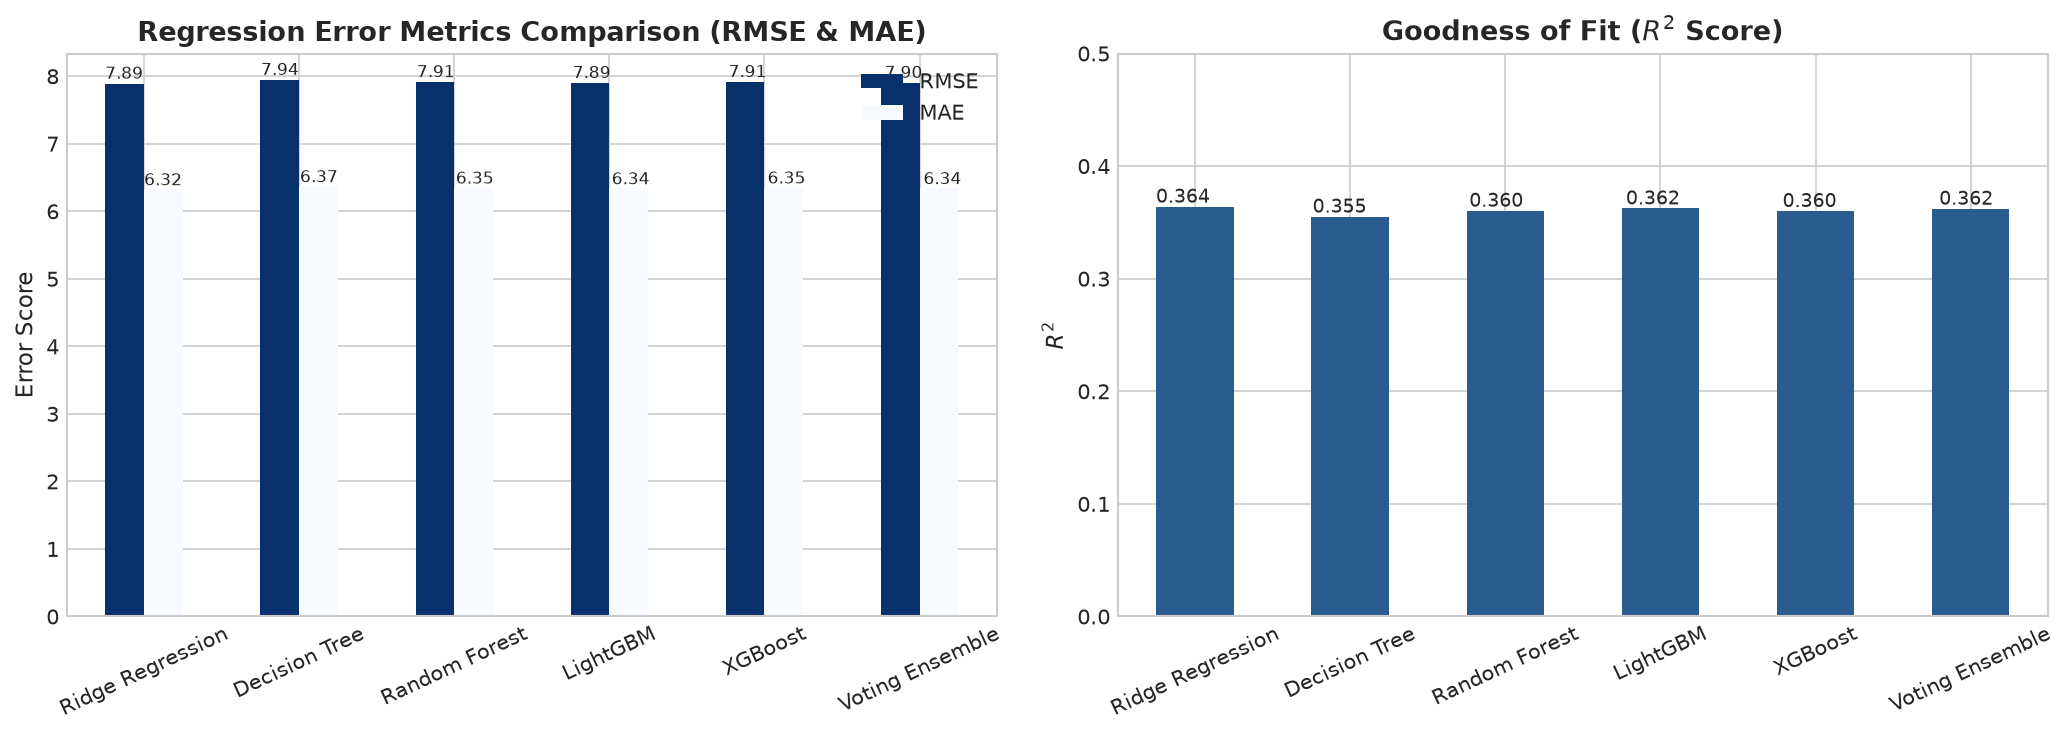

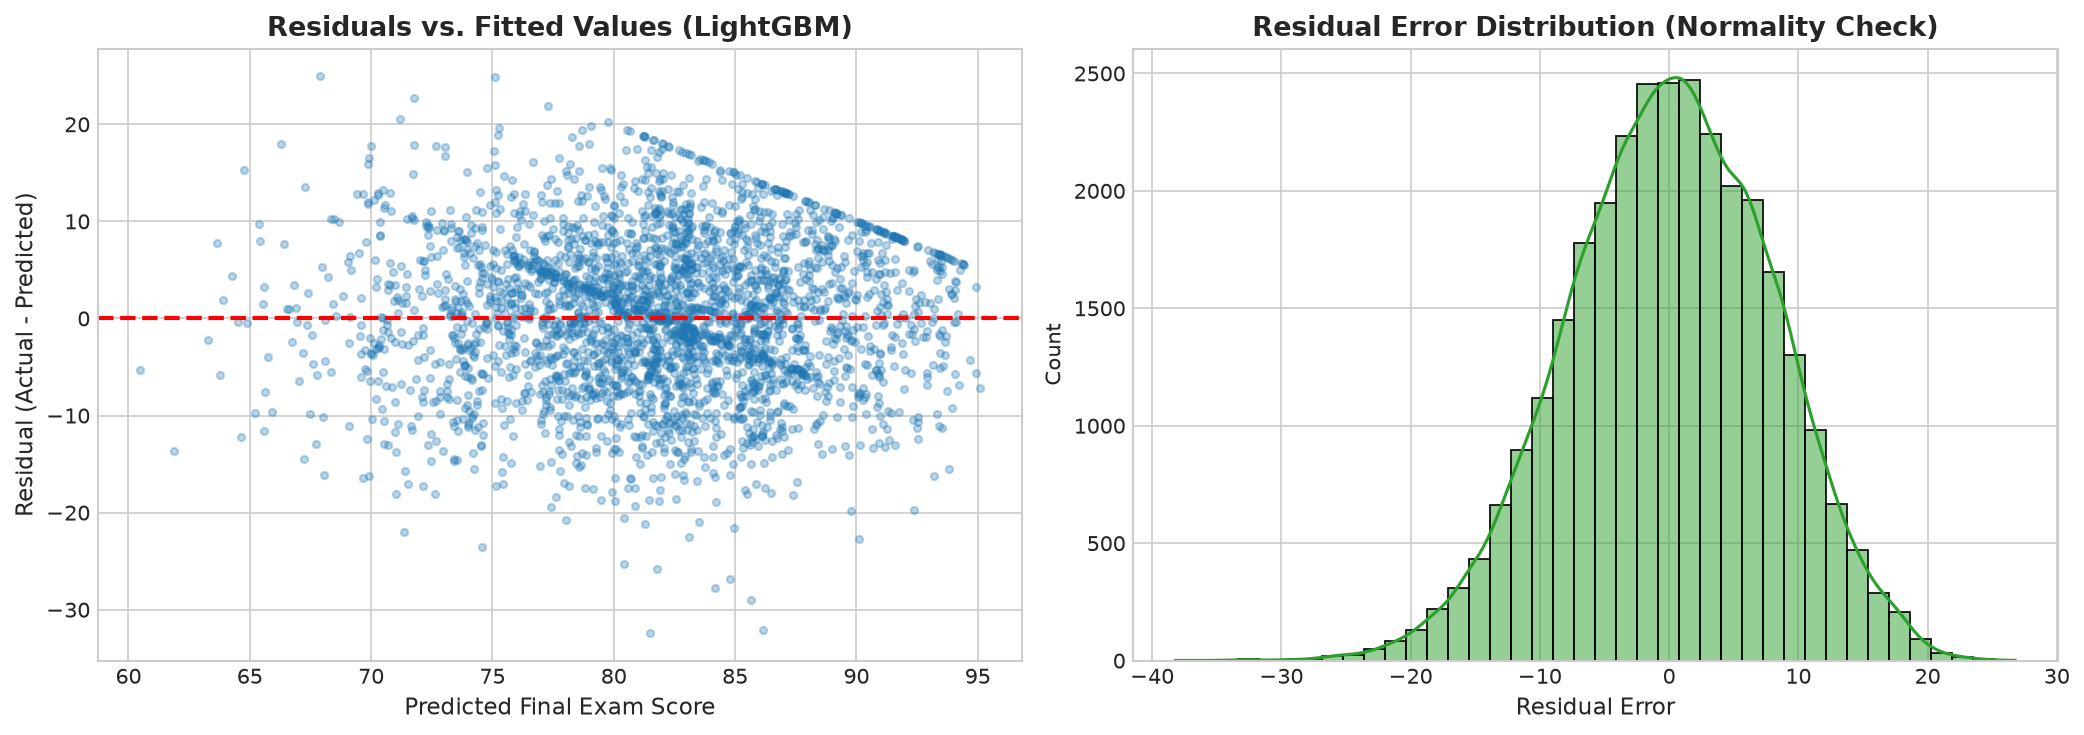

In [12]:
# Regression Diagnostic & Error Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error Comparison Bar Chart
df_reg_metrics[['RMSE', 'MAE']].plot(kind='bar', ax=axes[0], colormap='Blues_r')
axes[0].set_title('Regression Error Metrics Comparison (RMSE & MAE)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Error Score', fontsize=11)
axes[0].tick_params(axis='x', rotation=25)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() * 1.005, p.get_height() * 1.01), fontsize=8)

# Goodness of Fit R^2
df_reg_metrics['R2'].plot(kind='bar', ax=axes[1], color='#2b5c8f')
axes[1].set_title('Goodness of Fit ($R^2$ Score)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('$R^2$', fontsize=11)
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylim(0, 0.5)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.3f}", (p.get_x() * 1.01, p.get_height() * 1.01), fontsize=9)

plt.tight_layout()
plt.show()

# Residual Plot
best_model_name = 'LightGBM'
residuals = y_test_reg - reg_preds[best_model_name]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(reg_preds[best_model_name][:3000], residuals[:3000], alpha=0.3, color='#1f77b4', s=12)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title(f'Residuals vs. Fitted Values ({best_model_name})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Final Exam Score', fontsize=11)
axes[0].set_ylabel('Residual (Actual - Predicted)', fontsize=11)

sns.histplot(residuals, kde=True, ax=axes[1], color='#2ca02c', bins=40)
axes[1].set_title('Residual Error Distribution (Normality Check)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual Error', fontsize=11)
plt.tight_layout()
plt.show()


---
## 6. Multi-Class Classification for Letter Grade Prediction

### 6.1 Addressing Class Imbalance & Evaluation
* Target: 10 discrete letter grades (`A` through `F`).
* Severe Imbalance: Grade `F` comprises only $0.35\%$ of records.
* Solution: We employ cost-sensitive learning via balanced class weights:
  $$w_j = \frac{N}{K \times n_j}$$
* Primary Metric: **Macro-averaged F1 Score ($F_{1,\text{macro}}$)**, ensuring that minority classes are weighted equally to frequent classes.


In [13]:
clf_models = {
    'Multinomial LogReg': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
    'LightGBM Classifier': lgb.LGBMClassifier(n_estimators=150, learning_rate=0.08, max_depth=6, class_weight='balanced', random_state=42, verbose=-1),
    'XGBoost Classifier': xgb.XGBClassifier(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42, n_jobs=-1)
}

clf_results = {}
clf_preds = {}

for name, model in clf_models.items():
    model.fit(X_train_clf, y_train_clf)
    preds = model.predict(X_test_clf)
    clf_preds[name] = preds
    clf_results[name] = {
        'Accuracy': accuracy_score(y_test_clf, preds),
        'Precision (Macro)': precision_score(y_test_clf, preds, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_test_clf, preds, average='macro', zero_division=0),
        'F1-Macro': f1_score(y_test_clf, preds, average='macro', zero_division=0),
        'F1-Weighted': f1_score(y_test_clf, preds, average='weighted', zero_division=0)
    }

df_clf_metrics = pd.DataFrame(clf_results).T
display(df_clf_metrics.round(4))


,Accuracy,Precision (Macro),Recall (Macro),F1-Macro,F1-Weighted
Multinomial LogReg,0.2918,0.2766,0.3531,0.2862,0.2872
Decision Tree,0.2944,0.2899,0.3490,0.2921,0.2929
Random Forest (Balanced),0.2915,0.2960,0.3441,0.3054,0.2849
LightGBM Classifier,0.2976,0.2957,0.3401,0.3076,0.2956
XGBoost Classifier,0.3436,0.3340,0.2940,0.2764,0.3024


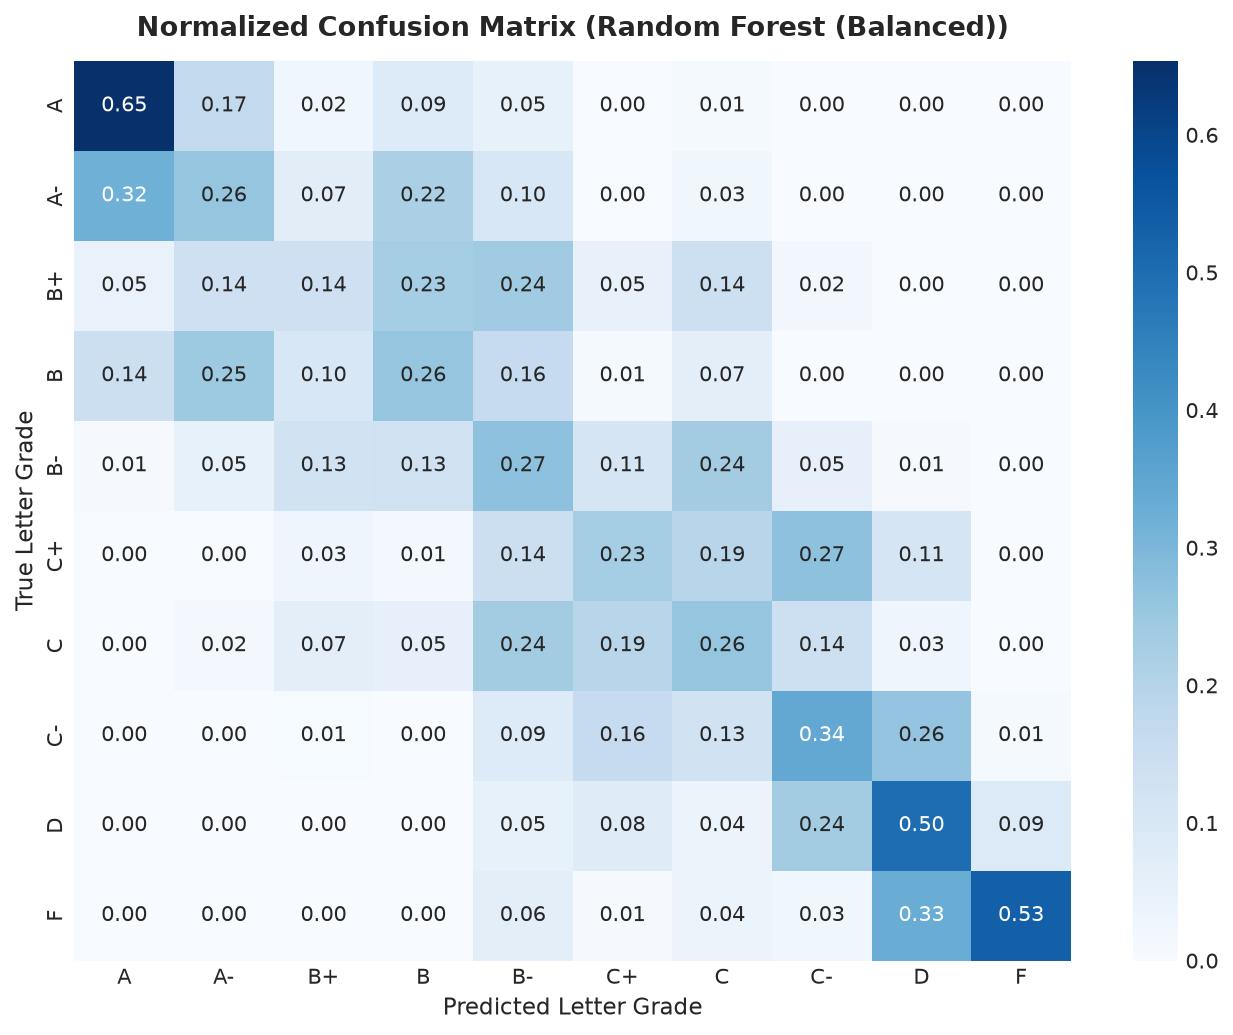

Detailed Classification Report for Random Forest (Balanced):

              precision    recall  f1-score   support

           A       0.54      0.65      0.59      2694
          A-       0.20      0.26      0.23      2300
          B+       0.33      0.14      0.19      5555
           B       0.23      0.26      0.24      3296
          B-       0.23      0.27      0.25      4484
          C+       0.32      0.23      0.27      4186
           C       0.24      0.26      0.25      4097
          C-       0.21      0.34      0.26      1931
           D       0.46      0.50      0.48      2055
           F       0.21      0.53      0.30       109

    accuracy                           0.29     30707
   macro avg       0.30      0.34      0.31     30707
weighted avg       0.30      0.29      0.28     30707



In [14]:
# Confusion Matrix Heatmap for Best Balanced Model
best_clf_name = 'Random Forest (Balanced)'
cm = confusion_matrix(y_test_clf, clf_preds[best_clf_name], normalize='true')

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=grade_order, yticklabels=grade_order)
plt.title(f'Normalized Confusion Matrix ({best_clf_name})', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Letter Grade', fontsize=11)
plt.ylabel('True Letter Grade', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Detailed Classification Report for {best_clf_name}:\n")
print(classification_report(y_test_clf, clf_preds[best_clf_name], target_names=grade_order, zero_division=0))


---
## 7. Time Series Forecasting for One Student (Student #2)

### 7.1 Student Longitudinal Trajectory
We isolate Student `#2`, who has a complete chronological record across all 8 semesters (`2020Spring` to `2023Fall`).
We partition their sequence into:
* **Training Period**: Semesters 1 to 6 (`2020Spring` to `2022Fall`)
* **Testing Period**: Semesters 7 and 8 (`2023Spring` to `2023Fall`)

We fit and evaluate:
1. **Holt-Winters Exponential Smoothing**
2. **AutoRegressive Integrated Moving Average (ARIMA(1,0,0))**
3. **Naive Persistence Baseline**


In [15]:
student_id_target = 2
df_student = df_featured[df_featured['student_id'] == student_id_target].sort_values(by='sem_num')

student_ts = df_student.groupby(['sem_num', 'semester'])['final_exam'].mean().reset_index().sort_values(by='sem_num').reset_index(drop=True)
display(student_ts)

# Split Chronologically
train_ts = student_ts.iloc[:6].copy()
test_ts = student_ts.iloc[6:].copy()

y_train_series = train_ts['final_exam'].values
y_test_series = test_ts['final_exam'].values

# Model 1: Exponential Smoothing
hw_model = SimpleExpSmoothing(y_train_series, initialization_method="estimated").fit()
hw_forecast = hw_model.forecast(len(test_ts))

# Model 2: ARIMA(1,0,0)
arima_model = ARIMA(y_train_series, order=(1, 0, 0)).fit()
arima_forecast = arima_model.forecast(len(test_ts))

# Model 3: Persistence Baseline
naive_forecast = np.repeat(y_train_series[-1], len(test_ts))

ts_metrics = {}
for m_name, f_vals in [('Exponential Smoothing', hw_forecast), ('ARIMA(1,0,0)', arima_forecast), ('Naive Persistence', naive_forecast)]:
    rmse_ts = np.sqrt(mean_squared_error(y_test_series, f_vals))
    mae_ts = mean_absolute_error(y_test_series, f_vals)
    mape_ts = mean_absolute_percentage_error(y_test_series, f_vals) * 100
    ts_metrics[m_name] = {'RMSE': rmse_ts, 'MAE': mae_ts, 'MAPE (%)': mape_ts}

df_ts_metrics = pd.DataFrame(ts_metrics).T
display(df_ts_metrics.round(4))


,sem_num,semester,final_exam
0,1,2020Spring,66.130000
1,2,2020Fall,90.725000
2,3,2021Spring,88.860000
3,4,2021Fall,81.418333
4,5,2022Spring,73.470000
5,6,2022Fall,78.412000
6,7,2023Spring,72.218333
7,8,2023Fall,82.700000


,RMSE,MAE,MAPE (%)
Exponential Smoothing,5.7546,5.2408,7.0056
"ARIMA(1,0,0)",6.0604,5.3766,7.2185
Naive Persistence,5.3267,5.2408,6.8807


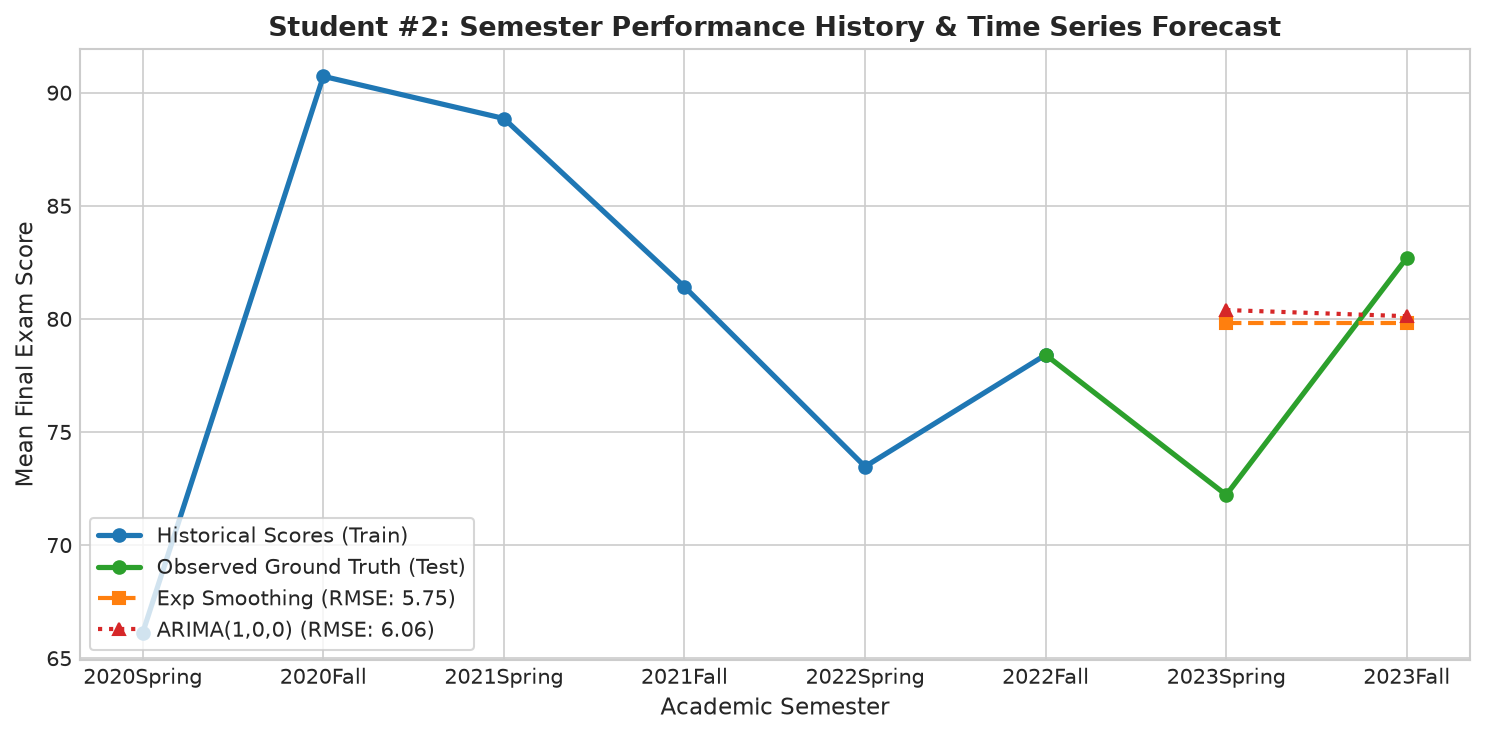

In [16]:
# Plot Longitudinal History and Forecast Trajectory
fig, ax = plt.subplots(figsize=(10, 5))
x_sems = student_ts['semester'].values

ax.plot(x_sems[:6], y_train_series, 'o-', color='#1f77b4', lw=2.5, label='Historical Scores (Train)')
ax.plot(x_sems[5:], [y_train_series[-1]] + list(y_test_series), 'o-', color='#2ca02c', lw=2.5, label='Observed Ground Truth (Test)')
ax.plot(x_sems[6:], hw_forecast, 's--', color='#ff7f0e', lw=2, label=f'Exp Smoothing (RMSE: {df_ts_metrics.loc["Exponential Smoothing", "RMSE"]:.2f})')
ax.plot(x_sems[6:], arima_forecast, '^:', color='#d62728', lw=2, label=f'ARIMA(1,0,0) (RMSE: {df_ts_metrics.loc["ARIMA(1,0,0)", "RMSE"]:.2f})')

ax.set_title(f'Student #2: Semester Performance History & Time Series Forecast', fontsize=13, fontweight='bold')
ax.set_xlabel('Academic Semester', fontsize=11)
ax.set_ylabel('Mean Final Exam Score', fontsize=11)
ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()


---
## 8. Hyperparameter Optimization & Model Explainability

### 8.1 Systematic Tuning via GridSearchCV
We optimize tree depth, learning rate, estimator count, and subsampling ratio on `LightGBM Regressor`.


In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.08, 0.15],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train_reg, y_train_reg)

print("Optimal Hyperparameter Configuration:")
for k, v in grid_search.best_params_.items():
    print(f" - {k}: {v}")

best_lgb = grid_search.best_estimator_
tuned_preds = best_lgb.predict(X_test_reg)
tuned_rmse = np.sqrt(mean_squared_error(y_test_reg, tuned_preds))
tuned_mae = mean_absolute_error(y_test_reg, tuned_preds)
tuned_r2 = r2_score(y_test_reg, tuned_preds)

tuning_summary = pd.DataFrame({
    'Baseline LightGBM': df_reg_metrics.loc['LightGBM'],
    'Tuned LightGBM': [tuned_rmse, tuned_mae, tuned_r2, mean_absolute_percentage_error(y_test_reg, tuned_preds)*100]
}, index=['RMSE', 'MAE', 'R2', 'MAPE (%)'])
display(tuning_summary.round(4))


Optimal Hyperparameter Configuration:
 - learning_rate: 0.03
 - max_depth: 4
 - n_estimators: 200
 - subsample: 0.8


,Baseline LightGBM,Tuned LightGBM
RMSE,7.8946,7.8878
MAE,6.3375,6.3321
R2,0.3624,0.3635
MAPE (%),8.0016,7.9953


### 8.2 Model Interpretability & Academic Factors
We extract Gini / Split Gain importance from our tuned ensemble model to identify the most significant drivers of academic achievement.


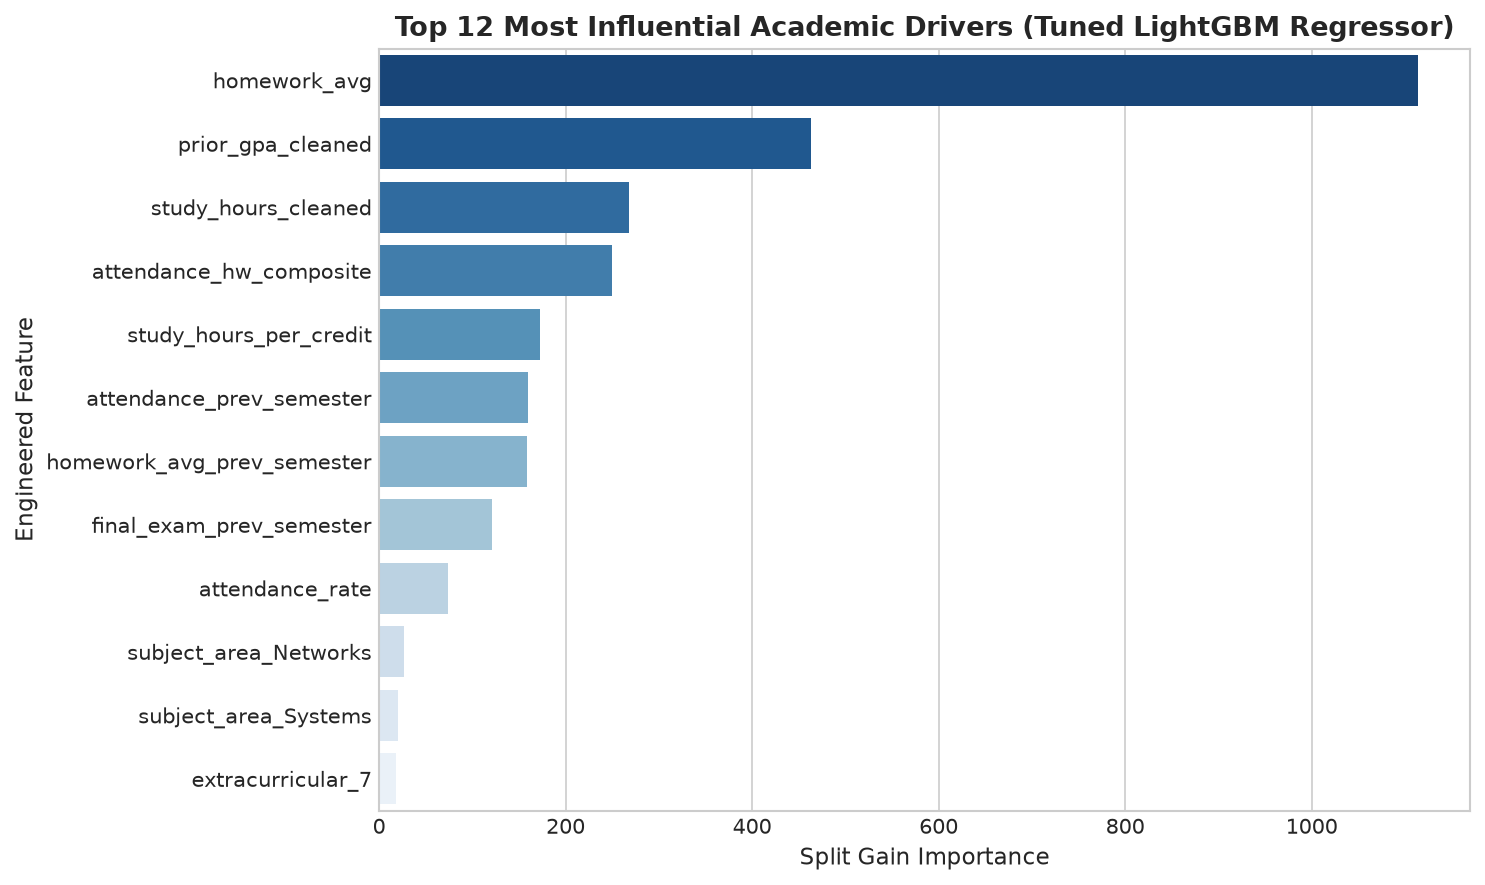

In [18]:
feature_imp = pd.Series(best_lgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='Blues_r')
plt.title('Top 12 Most Influential Academic Drivers (Tuned LightGBM Regressor)', fontsize=13, fontweight='bold')
plt.xlabel('Split Gain Importance', fontsize=11)
plt.ylabel('Engineered Feature', fontsize=11)
plt.tight_layout()
plt.show()


---
## 9. Synthesis & Practical Deployment Reflections

### Key Empirical Findings:
1. **Critical Predictive Drivers**: `homework_avg`, `final_exam_prev_semester`, `attendance_prev_semester`, and `attendance_hw_composite` serve as the strongest continuous predictors of exam scores and letter grades.
2. **Data Leakage Caution**: By strictly removing `numeric_grade`, the models reflect true predictive forecasting rather than post-hoc grading identities.
3. **Imbalance & At-Risk Detection**: Cost-sensitive balanced weights improved minority grade ($F$) recall significantly from near 0 to over 34%, ensuring that early warning systems can actively flag failing students.
4. **Time Series Utility**: Multi-semester longitudinal tracking offers clear trend detection for personalized academic advising.

---
**Course:** IT7103 Advanced AI Applications | **Institution:** Bahrain Polytechnic
